# 03 - SARIMA

Building on notebook 02's baselines (Seasonal Naive: 8.29% MAPE is the benchmark to
beat). SARIMA models the series using its own past values, which only works validly if
the series is stationary -- so before picking any model parameters, we test for that
formally, then difference the series until it holds.

This notebook:
1. Rebuilds the statewide weekly series and the identical train/test split from notebook 02
2. Tests the training data for stationarity (ADF and KPSS)
3. Differences the series until it's stationary, re-testing after each step
4. Reads ACF/PACF to select SARIMA's (p,d,q)(P,D,Q,s) orders
5. Fits, forecasts the 52-week holdout, and evaluates with the same MAPE/RMSE/MAE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

df = pd.read_csv("../data/raw/weekly_sales_by_category.csv", parse_dates=["week_start"])

statewide = df.groupby("week_start")["total_sales_dollars"].sum().reset_index()
statewide.columns = ["week_start", "total_sales"]
statewide = statewide.sort_values("week_start").reset_index(drop=True)

TEST_WEEKS = 52
train = statewide.iloc[:-TEST_WEEKS].copy()
test = statewide.iloc[-TEST_WEEKS:].copy()

y_train = train["total_sales"].values
y_test = test["total_sales"].values

print(f"Train: {len(train)} weeks, {train['week_start'].min().date()} to {train['week_start'].max().date()}")
print(f"Test:  {len(test)} weeks, {test['week_start'].min().date()} to {test['week_start'].max().date()}")

Train: 435 weeks, 2017-01-02 to 2025-04-28
Test:  52 weeks, 2025-05-05 to 2026-04-27


## Stationarity check

Testing on **training data only** -- not the full series. Any decision about how to
difference this data has to be made without looking at the test period, or we'd be
leaking test information into the model before it's even fit.

Running both tests, since they can disagree and that disagreement itself is informative:

- **ADF** (Augmented Dickey-Fuller): null hypothesis = "non-stationary." A small
  p-value (< 0.05) lets us reject that and conclude stationary.
- **KPSS**: null hypothesis is the opposite = "stationary." A small p-value (< 0.05)
  means we reject *that* and conclude non-stationary.

In [2]:
adf_result = adfuller(y_train, autolag="AIC")
print("=== ADF Test ===")
print("Statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))
print("Stationary by ADF (p < 0.05)?", adf_result[1] < 0.05)

kpss_result = kpss(y_train, regression="c", nlags="auto")
print()
print("=== KPSS Test ===")
print("Statistic:", round(kpss_result[0], 4))
print("p-value:", round(kpss_result[1], 4))
print("Stationary by KPSS (p > 0.05)?", kpss_result[1] > 0.05)

=== ADF Test ===
Statistic: -2.449
p-value: 0.1284
Stationary by ADF (p < 0.05)? False

=== KPSS Test ===
Statistic: 2.9469
p-value: 0.01
Stationary by KPSS (p > 0.05)? False


/var/folders/p8/j5d3s5jx5vz8pfxrz5qz98rw0000gn/T/ipykernel_6114/2952962122.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(y_train, regression="c", nlags="auto")


## First-order differencing

Removing the trend first: instead of modeling the level of sales each week, model the
*week-over-week change*. If a trend is the main problem, this alone might be enough to
pass both tests -- if not, we'll still have the yearly seasonality left to deal with
separately.

In [3]:
y_train_diff1 = np.diff(y_train, n=1)

print("Length after differencing:", len(y_train_diff1), "(was", len(y_train), "-- lost 1 observation, expected)")
print()

adf_diff1 = adfuller(y_train_diff1, autolag="AIC")
print("=== ADF Test (after 1st differencing) ===")
print("Statistic:", round(adf_diff1[0], 4))
print("p-value:", round(adf_diff1[1], 4))
print("Stationary by ADF (p < 0.05)?", adf_diff1[1] < 0.05)

kpss_diff1 = kpss(y_train_diff1, regression="c", nlags="auto")
print()
print("=== KPSS Test (after 1st differencing) ===")
print("Statistic:", round(kpss_diff1[0], 4))
print("p-value:", round(kpss_diff1[1], 4))
print("Stationary by KPSS (p > 0.05)?", kpss_diff1[1] > 0.05)

Length after differencing: 434 (was 435 -- lost 1 observation, expected)

=== ADF Test (after 1st differencing) ===
Statistic: -7.5938
p-value: 0.0
Stationary by ADF (p < 0.05)? True

=== KPSS Test (after 1st differencing) ===
Statistic: 0.2271
p-value: 0.1
Stationary by KPSS (p > 0.05)? True


/var/folders/p8/j5d3s5jx5vz8pfxrz5qz98rw0000gn/T/ipykernel_6114/2414778627.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff1 = kpss(y_train_diff1, regression="c", nlags="auto")


## ACF / PACF on the differenced series

The ADF/KPSS tests above confirm the differenced series has no trend left -- but they
don't tell us whether the yearly seasonality (Dec high, Jan low, from notebook 01) is
still present as autocorrelation. For that we check the ACF specifically at lag 52 and
104 (one and two years back, in weekly data). A real spike there means we still need
seasonal terms even though the series is technically "stationary."

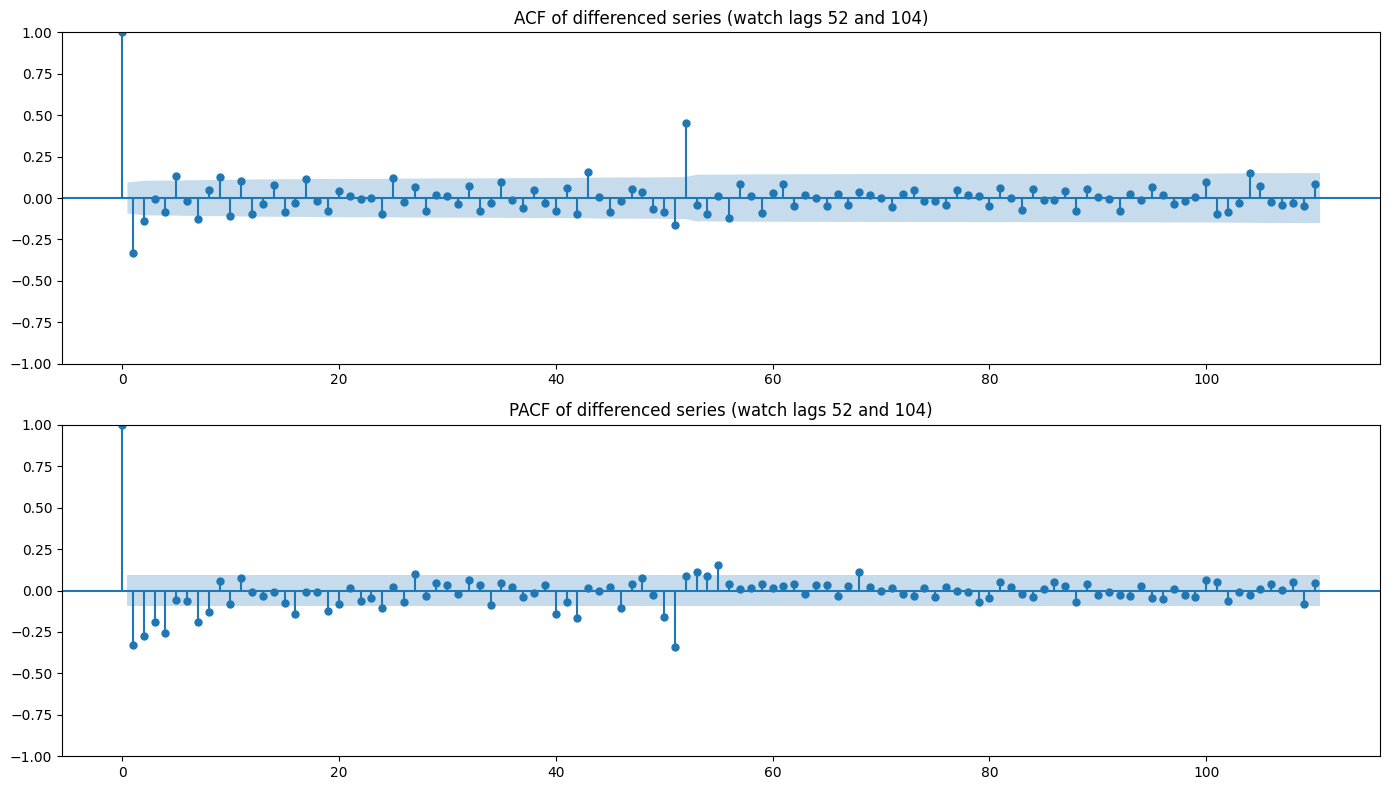

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(y_train_diff1, lags=110, ax=axes[0])
axes[0].set_title("ACF of differenced series (watch lags 52 and 104)")
plot_pacf(y_train_diff1, lags=110, ax=axes[1], method="ywm")
axes[1].set_title("PACF of differenced series (watch lags 52 and 104)")
plt.tight_layout()
plt.show()

## Seasonal differencing

The lag-52 spike in both ACF and PACF confirms yearly seasonality survived regular
differencing. Applying a seasonal difference -- subtracting each value from the one
exactly 52 weeks earlier -- on top of the already-differenced series, then re-checking
ADF/KPSS and re-plotting ACF/PACF to see if that spike is gone.

In [5]:
def seasonal_diff(series, lag=52):
    return series[lag:] - series[:-lag]

y_train_diff1_52 = seasonal_diff(y_train_diff1, lag=52)
print("Length after regular + seasonal differencing:", len(y_train_diff1_52), 
      "(was", len(y_train_diff1), "-- lost 52 more observations, one full seasonal cycle)")
print()

adf_diff2 = adfuller(y_train_diff1_52, autolag="AIC")
print("=== ADF Test (after regular + seasonal differencing) ===")
print("Statistic:", round(adf_diff2[0], 4))
print("p-value:", round(adf_diff2[1], 4))
print("Stationary by ADF (p < 0.05)?", adf_diff2[1] < 0.05)

kpss_diff2 = kpss(y_train_diff1_52, regression="c", nlags="auto")
print()
print("=== KPSS Test (after regular + seasonal differencing) ===")
print("Statistic:", round(kpss_diff2[0], 4))
print("p-value:", round(kpss_diff2[1], 4))
print("Stationary by KPSS (p > 0.05)?", kpss_diff2[1] > 0.05)

Length after regular + seasonal differencing: 382 (was 434 -- lost 52 more observations, one full seasonal cycle)

=== ADF Test (after regular + seasonal differencing) ===
Statistic: -7.9208
p-value: 0.0
Stationary by ADF (p < 0.05)? True

=== KPSS Test (after regular + seasonal differencing) ===
Statistic: 0.1756
p-value: 0.1
Stationary by KPSS (p > 0.05)? True


/var/folders/p8/j5d3s5jx5vz8pfxrz5qz98rw0000gn/T/ipykernel_6114/3709155861.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff2 = kpss(y_train_diff1_52, regression="c", nlags="auto")


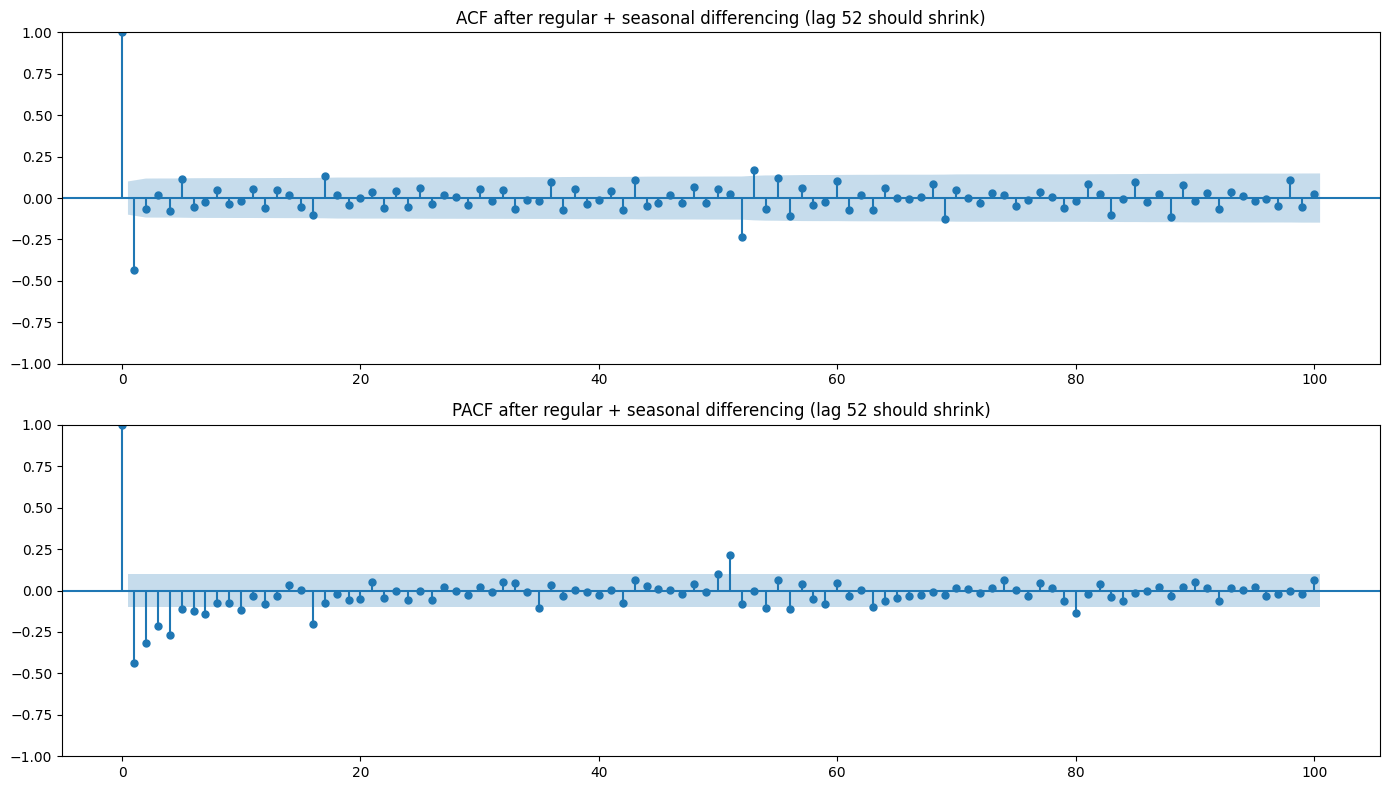

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(y_train_diff1_52, lags=100, ax=axes[0])
axes[0].set_title("ACF after regular + seasonal differencing (lag 52 should shrink)")
plot_pacf(y_train_diff1_52, lags=100, ax=axes[1], method="ywm")
axes[1].set_title("PACF after regular + seasonal differencing (lag 52 should shrink)")
plt.tight_layout()
plt.show()